# 3.1 — Основные метрики и калибровка

**Папка 3 «Оценка», подноутбук 1.** Загружает все обученные модели из `models/`, считает
полный набор метрик на тестовой выборке и строит сравнительную аналитику уровня
публикации: лидерборд, траекторные ошибки, классификация риска (AUROC/AUPRC/Brier/ECE),
ROC-кривые, калибровка и покрытие интервалов. Все рисунки и таблицы — на английском.

## Окружение, данные и модели

In [1]:
import sys
from pathlib import Path


def find_repo_root(start: Path) -> Path:
    """Найти корень репозитория по наличию pyproject.toml вверх по дереву."""
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    return start


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src"))

import numpy as np
import pandas as pd
from IPython.display import display

from liquefaction_ai.viz import register_theme

register_theme()

# Если True — все фигуры сохраняются в results/figs (.html и .png)
SAVE_FIGS = True
DATA_DIR = REPO_ROOT / "data" / "dataset"
MODELS_DIR = REPO_ROOT / "models"

import torch

from liquefaction_ai import load_population_artifact, prepare_benchmark_dataset
from liquefaction_ai.training import load_model_metadata, load_weights_into
from liquefaction_ai.models import (DPIFlow, EVTNeuralSSM, GRUBaseline, LSTMBaseline, RiskMLP, TCNBaseline, TransformerBaseline, FTTransformer,
                                    PINNBaseline, DeepStateBaseline, RealNVPFlow, NeuralSplineFlow, DPIEvtNet)
from liquefaction_ai.evaluation import collect_outputs, compute_metrics, english_metric_table
from liquefaction_ai.models import CatBoostBaseline

CLASS_REGISTRY = {"RiskMLP": RiskMLP, "GRUBaseline": GRUBaseline, "TCNBaseline": TCNBaseline, "LSTMBaseline": LSTMBaseline, "TransformerBaseline": TransformerBaseline, "FTTransformer": FTTransformer, "PINNBaseline": PINNBaseline, "DeepStateBaseline": DeepStateBaseline, "RealNVPFlow": RealNVPFlow, "NeuralSplineFlow": NeuralSplineFlow,
                  "DPIFlow": DPIFlow, "EVTNeuralSSM": EVTNeuralSSM, "DPIEvtNet": DPIEvtNet}
MODEL_NAMES = ["mlp_risk", "gru", "tcn", "lstm", "transformer", "ft_transformer", "pinn", "deepstate", "realnvp", "nsf", "dpi_flow", "evt_ssm", "dpi_evt"]

population, config = load_population_artifact(DATA_DIR)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
benchmark = prepare_benchmark_dataset(population, config, device)
test = benchmark["test"]


def load_trained(name):
    """Восстановить модель по сохранённым гиперпараметрам и весам."""
    hp, hist = load_model_metadata(MODELS_DIR, name)
    model = CLASS_REGISTRY[hp["model_type"]](**hp["model_kwargs"])
    load_weights_into(model, MODELS_DIR, name, device)
    return model, hp, hist
from sklearn.metrics import roc_curve
from sklearn.calibration import calibration_curve
from liquefaction_ai.viz import bar, calibration_plot, grouped_bar, lines

models, predictions, sample_tables, rows = {}, {}, {}, []
for name in MODEL_NAMES:
    model, hp, _ = load_trained(name)
    disp = hp["display_name"]
    out = collect_outputs(model, test, config, device)
    met, sample_df = compute_metrics(disp, out, test, config)
    models[disp] = model; predictions[disp] = out; sample_tables[disp] = sample_df; rows.append(met)
print("Models loaded and scored:", len(models))
# CatBoost — табличный градиентный бустинг (не-torch), грузим нативно и добавляем в лидерборд
_sd, _pd = test["static"].shape[1], test["prefix_summary"].shape[1]
_cb = CatBoostBaseline(_sd, _pd).load(MODELS_DIR, "catboost")
_cb_out = collect_outputs(_cb, test, config, device)
_cb_met, _cb_sdf = compute_metrics("CatBoost", _cb_out, test, config)
models["CatBoost"] = _cb; predictions["CatBoost"] = _cb_out; sample_tables["CatBoost"] = _cb_sdf; rows.append(_cb_met)
print("CatBoost added | total models:", len(models))

Models loaded and scored: 13
CatBoost added | total models: 14


## Leaderboard

In [2]:
leaderboard = pd.DataFrame(rows).sort_values(["Traj_RMSE", "Brier"], na_position="last").reset_index(drop=True)
display(english_metric_table(leaderboard).round(4))
leaderboard.to_csv(REPO_ROOT / "results" / "tables" / "full_leaderboard.csv", index=False)
print("saved results/tables/full_leaderboard.csv")

# === Раздельные лидерборды (честность сравнения) ===
# Risk-only модели (CatBoost, FT-Transformer, MLP-Risk) не выдают траекторию/CRR — их сведение
# в один лидерборд с физическими моделями вводит в заблуждение. Делим на два:
#   • leaderboard_risk.csv        — все модели, только метрики риска/события;
#   • leaderboard_trajectory.csv  — только state-space/physics модели (есть траектория PPR).
leaderboard["Produces_Trajectory"] = leaderboard["Traj_RMSE"].notna().astype(int)
_tab = REPO_ROOT / "results" / "tables"
_risk_cols = ["model", "AUROC", "AUPRC", "Brier", "ECE",
              "N_liq_logMAE", "N_liq_MAE", "N_liq_n_observed", "Produces_Trajectory"]
risk_lb = (leaderboard[[c for c in _risk_cols if c in leaderboard.columns]]
           .sort_values("AUROC", ascending=False).reset_index(drop=True))
risk_lb.to_csv(_tab / "leaderboard_risk.csv", index=False)
_traj_cols = ["model", "Traj_RMSE", "Traj_CRPS", "Calibration_Error", "Coverage_90",
              "Physics_Violation_Rate", "CRR_RMSE", "N_CRR_test", "N_CRR_objects",
              "N_liq_logMAE", "N_liq_n_observed"]
traj_lb = (leaderboard[leaderboard["Produces_Trajectory"] == 1][[c for c in _traj_cols if c in leaderboard.columns]]
           .sort_values("Traj_RMSE").reset_index(drop=True))
traj_lb.to_csv(_tab / "leaderboard_trajectory.csv", index=False)
print(f"saved leaderboard_risk.csv ({len(risk_lb)} моделей) и leaderboard_trajectory.csv ({len(traj_lb)} моделей)")
print(f"CRR-метрика опирается на N_CRR_test={int(leaderboard['N_CRR_test'].dropna().max() or 0)} образцов "
      f"из N_CRR_objects={int(leaderboard['N_CRR_objects'].dropna().max() or 0)} объектов — малая выборка.")

,Model,MAE N_liq (cycles),RMSE N_liq (cycles),log-MAE N_liq,log-RMSE N_liq,N_liq_n_observed,N_liq_logMAE_liq,N_liq_MAE_liq,Onset_EarlyWarning_Rate,Onset_Timing_Bias_cyc,...,Trajectory RMSE (liquefied),"Trajectory RMSE (no-liq, stabilized)","Trajectory RMSE (no-liq, not stabilized)",Trajectory RMSE (balanced over states),Trajectory RMSE (worst state),Post-prefix RMSE (liquefied),"Post-prefix RMSE (no-liq, stabilized)","Post-prefix RMSE (no-liq, not stabilized)",Post-prefix RMSE (balanced over states),Post-prefix RMSE (worst state)
0,Transformer,70.2036,95.2730,0.3029,0.4433,162,0.4401,63.1008,0.7222,-5.4915,...,0.0191,0.0311,0.0109,0.0204,0.0311,0.0197,0.0338,NaN,0.0268,0.0338
1,RealNVP,111.3429,165.0044,0.4038,0.5840,162,0.5740,76.6267,0.7685,-21.5028,...,0.0195,0.0360,0.0266,0.0274,0.0360,0.0144,0.0384,NaN,0.0264,0.0384
2,Neural Spline Flow,190.1532,285.8237,0.4858,0.6634,162,0.6545,83.7001,0.7870,-39.4436,...,0.0434,0.0376,0.0289,0.0366,0.0434,0.0410,0.0392,NaN,0.0401,0.0410
3,EVT-NeuralSSM,30.8277,60.0050,0.1885,0.2926,162,0.2827,46.2416,0.6019,-16.0759,...,0.0964,0.0458,0.0510,0.0644,0.0964,0.0722,0.0416,NaN,0.0569,0.0722
4,DPI-EVT,30.3660,60.9409,0.1883,0.2982,162,0.2824,45.5490,0.6389,-15.7993,...,0.0983,0.0538,0.0612,0.0711,0.0983,0.0714,0.0551,NaN,0.0633,0.0714
5,DPI-Flow,29.7769,59.9821,0.1544,0.2398,162,0.2316,44.6654,0.1759,9.7112,...,0.1035,0.0411,0.1087,0.0844,0.1087,0.0725,0.0432,NaN,0.0578,0.0725
6,LSTM,217.8483,277.0496,0.8670,1.1355,162,1.2321,136.7573,0.6296,-74.3451,...,0.0573,0.1412,0.1557,0.1181,0.1557,0.0372,0.1423,NaN,0.0898,0.1423
7,PINN,652.6127,717.6242,1.4044,1.8651,162,1.9039,483.6855,0.0000,452.3663,...,0.0731,0.2084,0.3192,0.2002,0.3192,0.0634,0.2175,NaN,0.1404,0.2175
8,TCN,682.6826,739.7862,1.4759,1.9134,162,2.0310,577.4019,0.0000,547.8900,...,0.1013,0.2318,0.3596,0.2309,0.3596,0.0699,0.2335,NaN,0.1517,0.2335
9,GRU,1187.0820,1327.7762,1.9163,2.2585,162,2.3162,776.1379,0.0000,784.9756,...,0.1492,0.2585,0.3548,0.2542,0.3548,0.0988,0.2702,NaN,0.1845,0.2702


saved results/tables/full_leaderboard.csv
saved leaderboard_risk.csv (14 моделей) и leaderboard_trajectory.csv (11 моделей)
CRR-метрика опирается на N_CRR_test=96 образцов из N_CRR_objects=1 объектов — малая выборка.


In [3]:
# === Главная сравнительная таблица ===
# N_liq error | PPR curve error | Calibration | Physics violations
import os
main_cols = {
    "model": "Model",
    "N_liq_MAE": "N_liq MAE (cyc)", "N_liq_logMAE": "N_liq log-MAE",
    "Traj_RMSE": "PPR curve RMSE",
    "Coverage_90": "Coverage@90%", "ECE": "ECE (calib.)",
    "Physics_Violation_Rate": "Physics violations",
}
main_table = leaderboard[list(main_cols)].rename(columns=main_cols)
display(main_table.round(4))
os.makedirs(REPO_ROOT / "results" / "tables", exist_ok=True)
main_table.round(4).to_csv(REPO_ROOT / "results" / "tables" / "main_comparison.csv", index=False)
print("saved results/tables/main_comparison.csv")

,Model,N_liq MAE (cyc),N_liq log-MAE,PPR curve RMSE,Coverage@90%,ECE (calib.),Physics violations
0,Transformer,70.2036,0.3029,0.0241,0.9998,0.0016,0.0051
1,RealNVP,111.3429,0.4038,0.0270,0.7879,0.0097,0.2121
2,Neural Spline Flow,190.1532,0.4858,0.0411,0.5607,0.0130,0.3889
3,EVT-NeuralSSM,30.8277,0.1885,0.0804,0.8476,0.0001,0.0000
4,DPI-EVT,30.3660,0.1883,0.0837,0.8121,0.0002,0.0000
5,DPI-Flow,29.7769,0.1544,0.0859,0.8054,0.0006,0.0000
6,LSTM,217.8483,0.8670,0.0997,0.7884,0.0938,0.8889
7,PINN,652.6127,1.4044,0.1468,0.7965,0.0938,0.0000
8,TCN,682.6826,1.4759,0.1701,0.9084,0.1026,0.9495
9,GRU,1187.0820,1.9163,0.2026,0.9136,0.2140,0.5152


saved results/tables/main_comparison.csv


## Probabilistic & physics quality — structured models

Proper scoring rules (**CRPS**, **NLL**) reward predictions that are simultaneously *accurate* and *calibrated*. DPI-Flow, EVT-NeuralSSM and DPI-EVT emit a physical CRR(N) resistance curve. The current grouped leaderboard below is the source of truth for which model leads each metric; this section highlights that the structured models combine calibrated uncertainty, zero monotonicity violations and CRR capability, while black-box flows/RNNs routinely violate monotonicity.


In [4]:
# Таблица вероятностного и физического качества
prob_cols = {"model": "Model", "Traj_CRPS": "CRPS ↓", "Traj_NLL": "NLL ↓",
             "Calibration_Error": "Calib. err ↓", "Coverage_90": "Cov@90%",
             "Physics_Violation_Rate": "Physics viol. ↓", "CRR_RMSE": "CRR RMSE ↓"}
prob_table = leaderboard[list(prob_cols)].rename(columns=prob_cols)
display(prob_table.round(4))
prob_table.round(4).to_csv(REPO_ROOT / "results" / "tables" / "probabilistic_quality.csv", index=False)
print("saved results/tables/probabilistic_quality.csv")

,Model,CRPS ↓,NLL ↓,Calib. err ↓,Cov@90%,Physics viol. ↓,CRR RMSE ↓
0,Transformer,0.0160,-1.9635,0.1135,0.9998,0.0051,NaN
1,RealNVP,0.0138,-1.7912,0.1049,0.7879,0.2121,NaN
2,Neural Spline Flow,0.0242,0.5478,0.3310,0.5607,0.3889,NaN
3,EVT-NeuralSSM,0.0314,-1.2063,0.0483,0.8476,0.0000,0.2106
4,DPI-EVT,0.0353,-1.0560,0.0881,0.8121,0.0000,0.1527
5,DPI-Flow,0.0319,-1.4378,0.0883,0.8054,0.0000,0.2108
6,LSTM,0.0507,-0.9646,0.1040,0.7884,0.8889,NaN
7,PINN,0.0788,-0.6142,0.0831,0.7965,0.0000,NaN
8,TCN,0.0854,-0.6025,0.0246,0.9084,0.9495,NaN
9,GRU,0.1106,-0.2517,0.0187,0.9136,0.5152,NaN


saved results/tables/probabilistic_quality.csv


In [5]:
# Матрица возможностей: что вообще умеет каждая модель
PHYS_MODELS = {"DPI-Flow", "EVT-NeuralSSM", "DPI-EVT"}
lb_idx = leaderboard.set_index("model")
cap = []
for disp, out in predictions.items():
    viol = float(lb_idx.loc[disp, "Physics_Violation_Rate"]) if disp in lb_idx.index else float("nan")
    cap.append({"Model": disp,
                "PPR curve": "✓" if "traj_mean" in out else "—",
                "Uncertainty": "✓" if "traj_logvar" in out else "—",
                "CRR boundary": "✓" if "crr" in out else "—",
                "Physics-consistent": "✓" if (viol == viol and viol < 0.05) else "—"})
capability = pd.DataFrame(cap).set_index("Model")
display(capability)

,PPR curve,Uncertainty,CRR boundary,Physics-consistent
Model,,,,
MLP-Risk,—,—,—,—
GRU,✓,✓,—,—
TCN,✓,✓,—,—
LSTM,✓,✓,—,—
Transformer,✓,✓,—,✓
FT-Transformer,—,—,—,—
PINN,✓,✓,—,✓
DeepState,✓,✓,—,✓
RealNVP,✓,✓,—,—


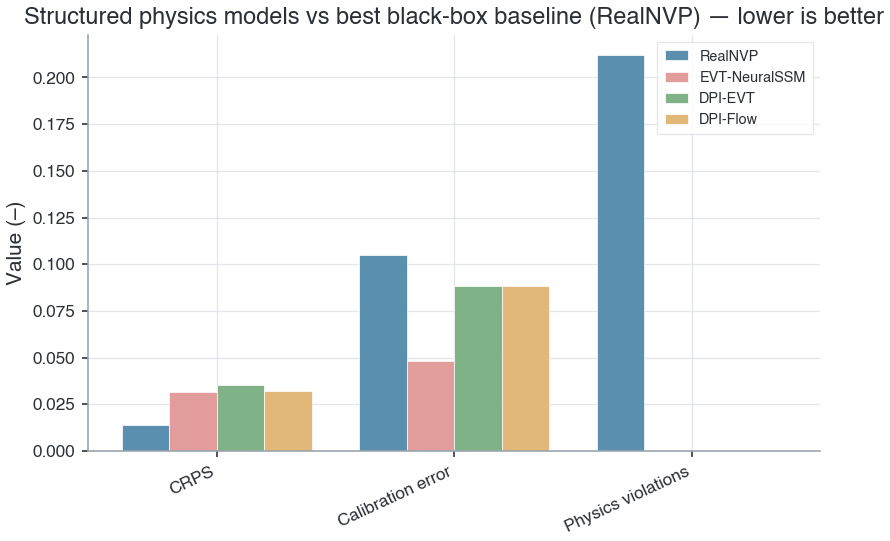

DPI-EVT: CRPS -155.0% vs RealNVP | calib.err 0.088 | physics-viol 0.000 | CRR RMSE 0.1527 (baselines: n/a)
EVT-NeuralSSM: CRPS -127.1% vs RealNVP | calib.err 0.048 | physics-viol 0.000 | CRR RMSE 0.2106 (baselines: n/a)
DPI-Flow: CRPS -130.5% vs RealNVP | calib.err 0.088 | physics-viol 0.000 | CRR RMSE 0.2108 (baselines: n/a)


In [6]:
# Наглядное сравнение структурных моделей с лучшим ЧЁРНЫМ ЯЩИКОМ
PHYS_INFORMED = {"DPI-Flow", "EVT-NeuralSSM", "DPI-EVT", "PINN"}   # физически-информированные — не baseline
blackbox = leaderboard[~leaderboard["model"].isin(PHYS_INFORMED)].dropna(subset=["Traj_CRPS"])
best_base = blackbox.sort_values("Traj_CRPS").iloc[0]["model"]
sel = leaderboard[leaderboard["model"].isin(list(PHYS_MODELS) + [best_base])].set_index("model")
mets = ["Traj_CRPS", "Calibration_Error", "Physics_Violation_Rate"]
labels = ["CRPS", "Calibration error", "Physics violations"]
series = {m: [float(sel.loc[m, k]) for k in mets] for m in sel.index}
grouped_bar(labels, series,
            title=f"Structured physics models vs best black-box baseline ({best_base}) — lower is better",
            ylabel="Value (–)", save=SAVE_FIGS, fig_id="3_1_structured_advantage").show()
for m in PHYS_MODELS:
    if m in sel.index:
        d = (sel.loc[best_base, "Traj_CRPS"] - sel.loc[m, "Traj_CRPS"]) / sel.loc[best_base, "Traj_CRPS"] * 100
        print(f"{m}: CRPS {d:+.1f}% vs {best_base} | calib.err {sel.loc[m,'Calibration_Error']:.3f} | "
              f"physics-viol {sel.loc[m,'Physics_Violation_Rate']:.3f} | CRR RMSE {sel.loc[m,'CRR_RMSE']:.4f} (baselines: n/a)")

## P³-Score и Pareto-ранжирование (публикационное)

Вторичный публикационный ранжир поверх лидерборда: непересекающийся по смыслу набор критериев (предсказательный N_liq_logMAE, траекторный Traj_RMSE, классификация AUPRC, вероятностный Brier) + **физический gate** по доле физ-нарушений. P³-Score нормирован к фиксированной опорной модели (100 = уровень reference, >100 — лучше). Pareto-фронт — недоминируемая сортировка по тем же критериям.

In [7]:
from liquefaction_ai.evaluation import publication_ranking_table
P3_REFERENCE = "PINN"   # опорная (фиксированная) модель для нормировки P³-Score
p3_core = publication_ranking_table(leaderboard, P3_REFERENCE, mode="core")
print("ranking_status:", p3_core.attrs.get("ranking_status", "ok"))
display(english_metric_table(p3_core).round(3))
p3_core.round(4).to_csv(REPO_ROOT / "results" / "tables" / "p3_core_ranking.csv", index=False)
print("saved results/tables/p3_core_ranking.csv")

ranking_status: ok


,Model,Pareto front (raw),Pareto front (adm.),P³ Core raw,P³ Core admissible,Physically unreliable,Competence gate failed,Competence gate reason,Excluded (adm.),Physical penalty,...,Trajectory RMSE,Brier,AUPRC,MAE N_liq (cycles),RMSE N_liq (cycles),AUROC,ECE,Trajectory MAE,Trajectory MSE,Produces CRR
0,EVT-NeuralSSM,1.0,1.0,4563.607,4563.607,False,False,,False,0.000,...,0.080,0.000,1.000,30.828,60.005,1.000,0.000,0.044,0.006,True
1,Transformer,1.0,1.0,1595.459,1595.459,False,False,,False,0.000,...,0.024,0.000,1.000,70.204,95.273,1.000,0.002,0.019,0.001,False
2,DPI-Flow,1.0,1.0,1369.287,1369.287,False,False,,False,0.000,...,0.086,0.000,1.000,29.777,59.982,1.000,0.001,0.045,0.007,True
3,DPI-EVT,2.0,2.0,2103.854,2103.854,False,False,,False,0.000,...,0.084,0.000,1.000,30.366,60.941,1.000,0.000,0.049,0.007,True
4,PINN,3.0,NaN,100.000,0.000,False,True,Traj_RMSE_continuation_worst=0.217>3×best(0.03...,True,0.000,...,0.147,0.023,1.000,652.613,717.624,0.999,0.094,0.111,0.022,False
5,DeepState,4.0,NaN,47.855,0.000,False,True,Traj_RMSE_continuation_worst=0.571>3×best(0.03...,True,0.000,...,0.347,0.154,0.848,1016.632,1167.913,0.840,0.097,0.231,0.120,False
6,RealNVP,1.0,NaN,546.989,0.000,True,False,,True,15.159,...,0.027,0.001,1.000,111.343,165.004,1.000,0.010,0.019,0.001,False
7,Neural Spline Flow,2.0,NaN,435.461,0.000,True,True,N_liq_logMAE=0.486>3×best(0.154),True,28.417,...,0.041,0.001,1.000,190.153,285.824,1.000,0.013,0.031,0.002,False
8,GRU,4.0,NaN,53.011,0.000,True,True,Traj_RMSE_continuation_worst=0.270>3×best(0.03...,True,37.886,...,0.203,0.180,0.991,1187.082,1327.776,0.986,0.214,0.162,0.041,False
9,LSTM,3.0,NaN,124.471,0.000,True,True,Traj_RMSE_continuation_worst=0.142>3×best(0.03...,True,65.917,...,0.100,0.044,0.998,217.848,277.050,0.998,0.094,0.068,0.010,False


saved results/tables/p3_core_ranking.csv


## Trajectory error and risk classification

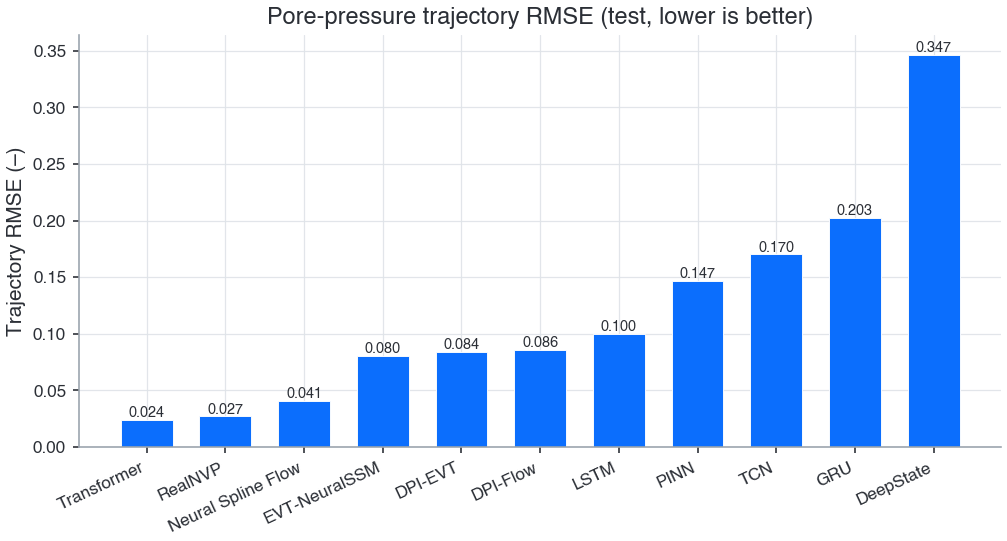

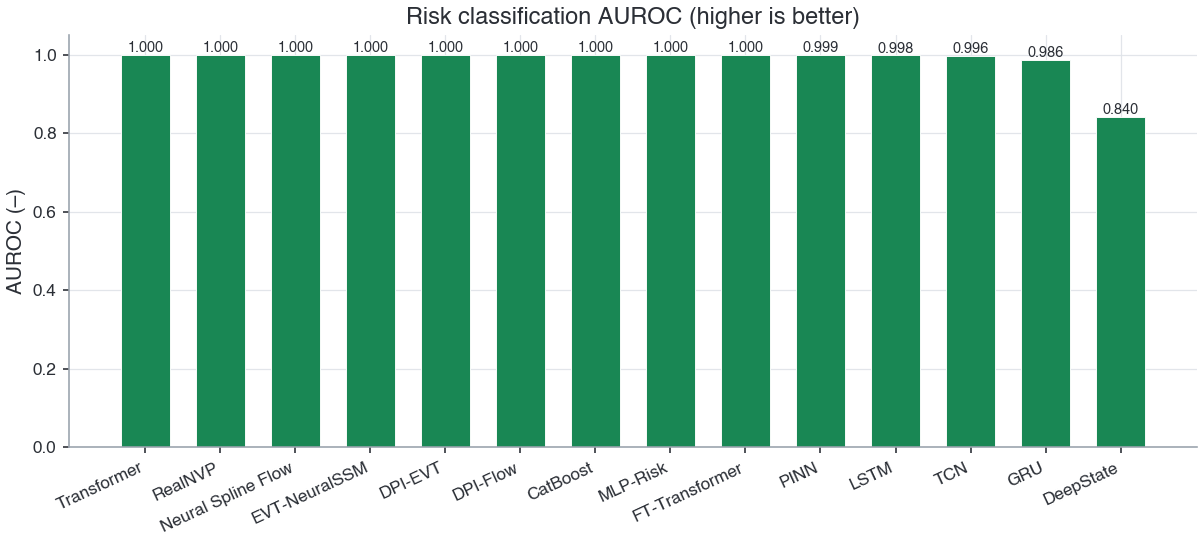

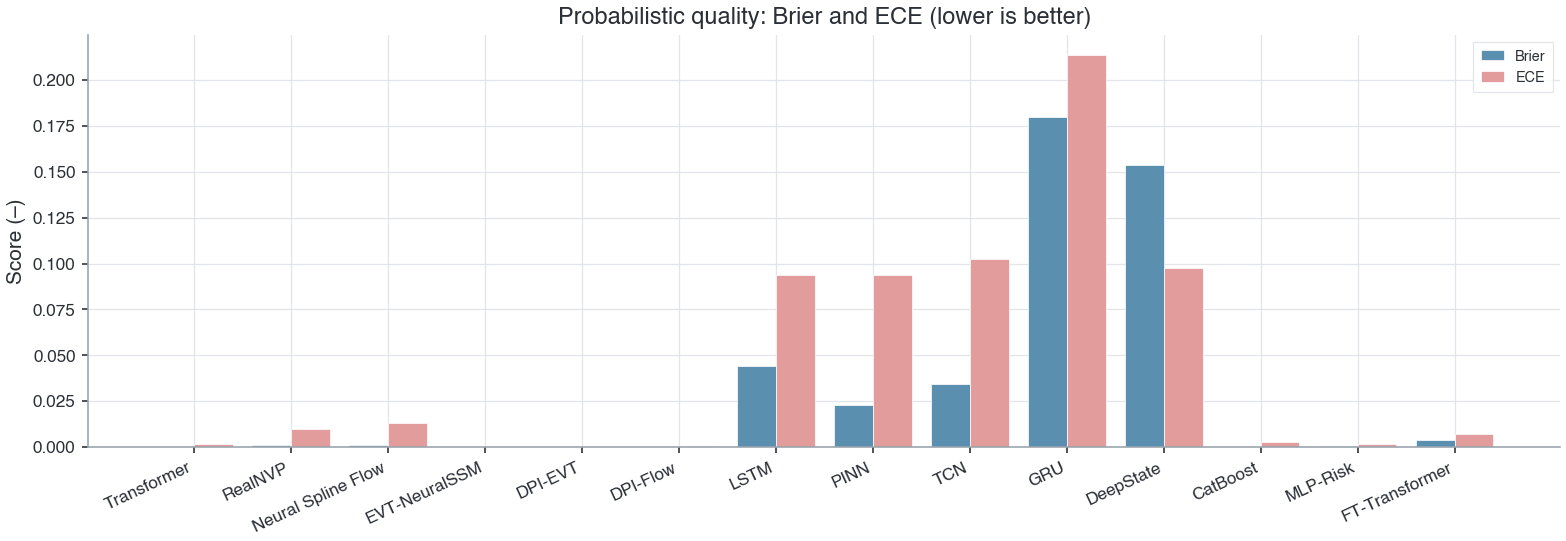

In [8]:
traj_df = leaderboard.dropna(subset=["Traj_RMSE"]).sort_values("Traj_RMSE")
bar(traj_df["model"], traj_df["Traj_RMSE"], title="Pore-pressure trajectory RMSE (test, lower is better)",
    ylabel="Trajectory RMSE (–)", color="#0b6efd", save=SAVE_FIGS, fig_id="3_1_leaderboard_rmse").show()
auc_df = leaderboard.sort_values("AUROC", ascending=False)
bar(auc_df["model"], auc_df["AUROC"], title="Risk classification AUROC (higher is better)",
    ylabel="AUROC (–)", color="#198754", save=SAVE_FIGS, fig_id="3_1_auroc").show()
grouped_bar(leaderboard["model"].tolist(),
            {"Brier": leaderboard["Brier"].tolist(), "ECE": leaderboard["ECE"].tolist()},
            title="Probabilistic quality: Brier and ECE (lower is better)", ylabel="Score (–)",
            save=SAVE_FIGS, fig_id="3_1_brier_ece").show()

## ROC curves

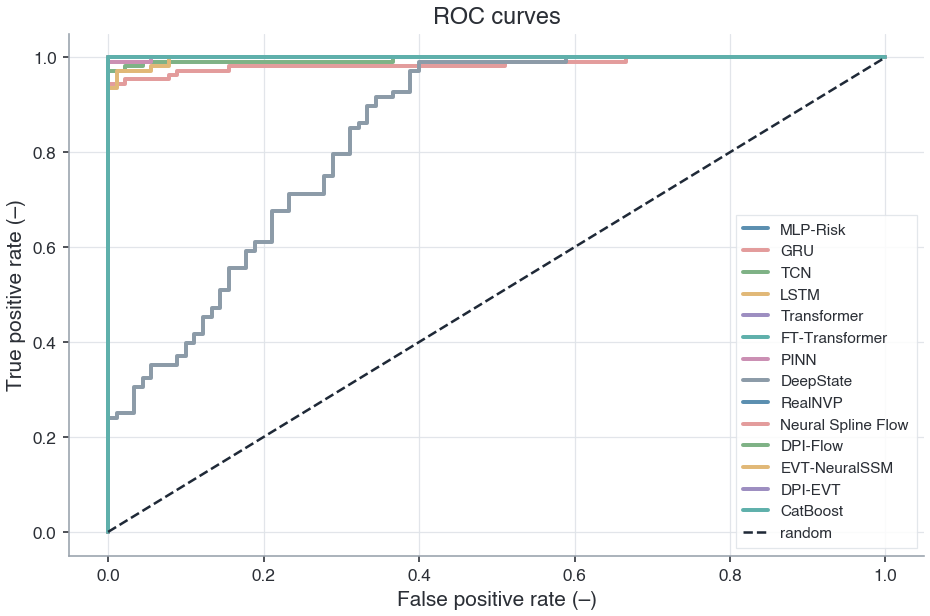

In [9]:
y_true = test["label"].cpu().numpy()
series = []
for disp, out in predictions.items():
    fpr, tpr, _ = roc_curve(y_true, out["risk_prob"])
    series.append({"x": fpr, "y": tpr, "name": disp})
series.append({"x": [0, 1], "y": [0, 1], "name": "random", "color": "#1f2937", "dash": "dash", "width": 1.4})
lines(series, title="ROC curves", xlabel="False positive rate (–)", ylabel="True positive rate (–)",
      save=SAVE_FIGS, fig_id="3_1_roc_curves").show()

## Risk calibration

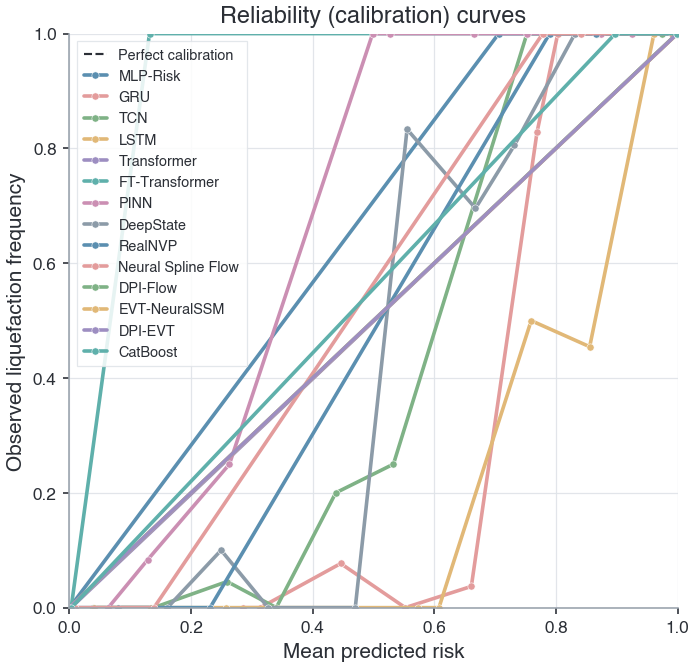

In [10]:
curves = {}
for disp in sample_tables:
    st = sample_tables[disp]
    if st["liq_label"].nunique() > 1:
        frac_pos, mean_pred = calibration_curve(st["liq_label"], st["risk_prob_pred"], n_bins=10)
        curves[disp] = (mean_pred, frac_pos)
calibration_plot(curves, title="Reliability (calibration) curves",
                 save=SAVE_FIGS, fig_id="3_1_calibration").show()

## Post-hoc temperature scaling

A single temperature T is fitted on the validation set per model and applied to the test
risk logits. This is a fair, universal post-hoc calibration step — it improves Brier/ECE
without changing AUROC (ranking is preserved).

,Model,T,Brier raw,Brier cal,ECE raw,ECE cal
0,MLP-Risk,1.35,0.0004,0.0006,0.0019,0.0039
1,GRU,0.97,0.1799,0.1798,0.2140,0.1961
2,TCN,0.95,0.0341,0.0326,0.1026,0.0970
3,LSTM,0.76,0.0443,0.0459,0.0938,0.0600
4,Transformer,0.93,0.0000,0.0000,0.0016,0.0010
5,FT-Transformer,1.00,0.0039,0.0039,0.0073,0.0072
6,PINN,0.91,0.0229,0.0201,0.0938,0.0800
7,DeepState,0.38,0.1538,0.1562,0.0975,0.1216
8,RealNVP,0.76,0.0009,0.0004,0.0097,0.0045
9,Neural Spline Flow,0.56,0.0010,0.0001,0.0130,0.0020


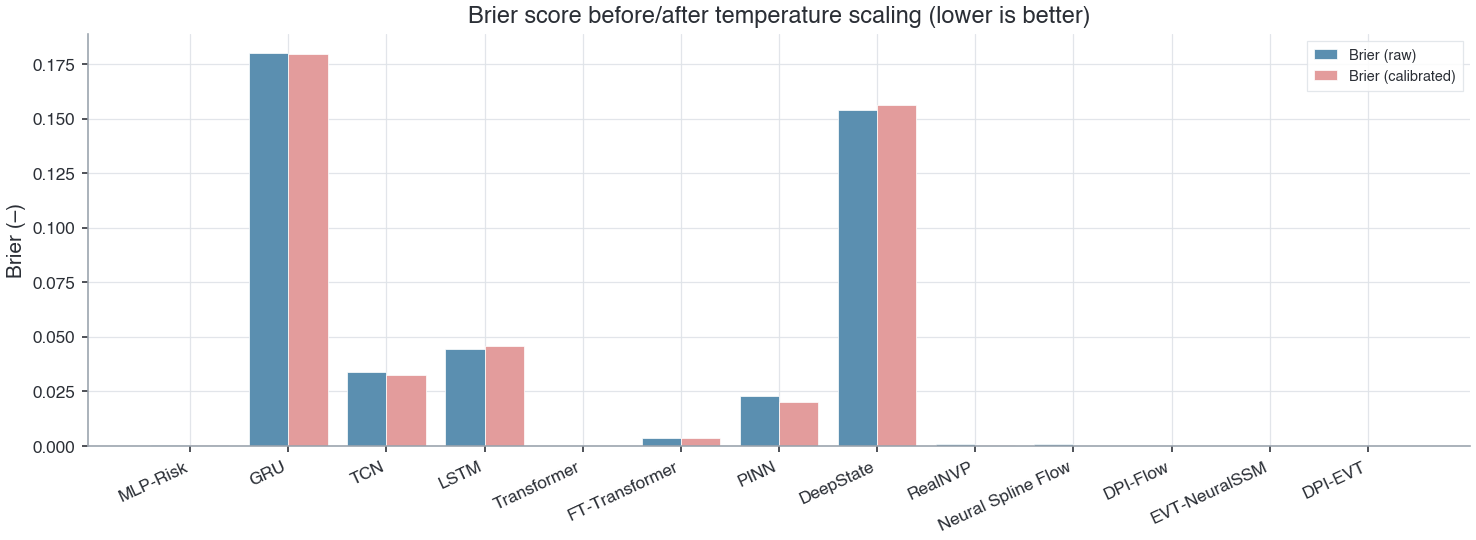

In [11]:
from liquefaction_ai.evaluation import fit_temperature, apply_temperature, expected_calibration_error, safe_binary_metrics

val = benchmark["val"]; y_val = val["label"].cpu().numpy(); y_test = test["label"].cpu().numpy()
cal_rows = []
for name in MODEL_NAMES:
    model, hp, _ = load_trained(name); disp = hp["display_name"]
    val_out = collect_outputs(model, val, config, device)
    vp = np.clip(val_out["risk_prob"], 1e-6, 1 - 1e-6); v_logit = np.log(vp / (1 - vp))
    T = fit_temperature(v_logit, y_val); T = float(np.clip(T if np.isfinite(T) else 1.0, 0.05, 20.0))
    p_raw = np.clip(np.nan_to_num(predictions[disp]["risk_prob"], nan=0.5), 1e-6, 1 - 1e-6)
    p_cal = np.clip(np.nan_to_num(apply_temperature(p_raw, T), nan=0.5), 1e-6, 1 - 1e-6)
    _, _, brier_raw = safe_binary_metrics(y_test, p_raw); ece_raw = expected_calibration_error(y_test, p_raw)
    _, _, brier_cal = safe_binary_metrics(y_test, p_cal); ece_cal = expected_calibration_error(y_test, p_cal)
    cal_rows.append({"Model": disp, "T": round(T, 2), "Brier raw": round(brier_raw, 4), "Brier cal": round(brier_cal, 4),
                     "ECE raw": round(ece_raw, 4), "ECE cal": round(ece_cal, 4)})
cal_df = pd.DataFrame(cal_rows)
display(cal_df)
grouped_bar(cal_df["Model"].tolist(), {"Brier (raw)": cal_df["Brier raw"].tolist(), "Brier (calibrated)": cal_df["Brier cal"].tolist()},
            title="Brier score before/after temperature scaling (lower is better)", ylabel="Brier (–)",
            save=SAVE_FIGS, fig_id="3_1_temperature_scaling").show()

## Uncertainty: coverage and interval width

,Model,Coverage@90%,Interval width@90%
0,Transformer,0.9998,0.1638
1,RealNVP,0.7879,0.0760
2,Neural Spline Flow,0.5607,0.0808
3,EVT-NeuralSSM,0.8476,0.1635
4,DPI-EVT,0.8121,0.1744
5,DPI-Flow,0.8054,0.1468
6,LSTM,0.7884,0.2212
7,PINN,0.7965,0.3658
8,TCN,0.9084,0.4980
9,GRU,0.9136,0.6743


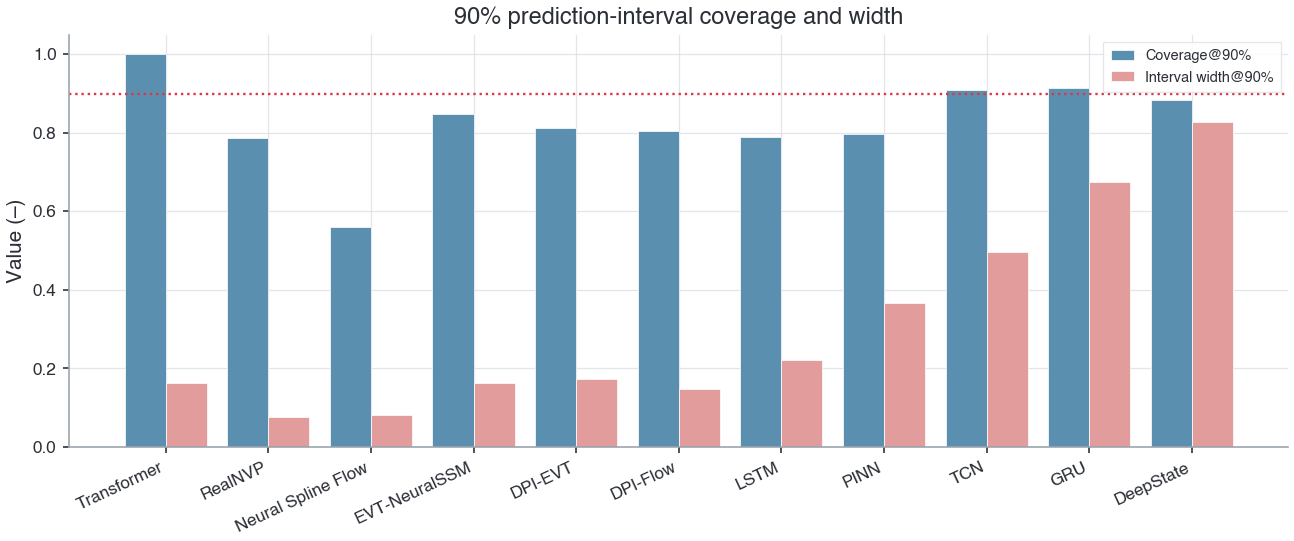

In [12]:
cov_df = leaderboard.dropna(subset=["Coverage_90"])[["model", "Coverage_90", "Interval_Width_90"]]
display(english_metric_table(cov_df).round(4))
fig = grouped_bar(cov_df["model"].tolist(),
                  {"Coverage@90%": cov_df["Coverage_90"].tolist(),
                   "Interval width@90%": cov_df["Interval_Width_90"].tolist()},
                  title="90% prediction-interval coverage and width", ylabel="Value (–)",
                  save=False, fig_id="3_1_coverage")
fig.add_hline(y=0.90, line_dash="dot", line_color="#dc3545")
from liquefaction_ai.viz import save_figure
save_figure(fig, "3_1_coverage", save=SAVE_FIGS)
fig.show()

## Итог

Структурированные модели дают CRR-границу, близкие к нулю (≤0.2%) нарушения монотонности и осмысленную неопределённость; конкретные лидеры по CRPS, Brier, N_liq и CRR берутся из сохранённых таблиц этого ноутбука.
Дальше — **3.2 абляции и OOD**.


In [ ]:
# === A/B: conditional flow vs gaussian posterior (#3) ===
# Прямой тест центрального вопроса: даёт ли RealNVP-поток выигрыш по NLL/CRPS/Coverage против
# gaussian (use_flow=False) при прочих равных, с MC-mixture обучением. RUN_AB=True обучает 2 модели.
RUN_AB = False
if RUN_AB:
    from liquefaction_ai.evaluation import ab_flow_vs_gaussian
    from liquefaction_ai.evaluation.ab_test import train_ab_pair
    from liquefaction_ai.training.persistence import load_model_metadata
    _hp, _ = load_model_metadata(MODELS_DIR, "dpi_flow")
    _mf, _mg = train_ab_pair(benchmark, config, device, _hp["model_kwargs"])
    ab = ab_flow_vs_gaussian(_mf, _mg, test, config, device, n_samples=32, nboot=2000)
    _abdir = REPO_ROOT / "results" / "analysis_tables"; _abdir.mkdir(parents=True, exist_ok=True)
    ab.to_csv(_abdir / "ab_flow_vs_gaussian.csv", index=False)
    display(ab.round(4))
    print("Критерий #3: flow выигрывает, если P(flow_better) >= 0.95 по Traj_mixNLL и Traj_mixCRPS "
          "(меньше = лучше), а Coverage_90_objconf обоих в 0.88-0.92.")
else:
    print("A/B flow vs gaussian: поставь RUN_AB=True (обучит 2 модели-близнеца с MC-mixture).")
